# ⚽ muFIFA — Predicting the 2026 FIFA World Cup Knockout Stage

**Football meets AI.** This notebook builds a machine-learning model that predicts the 2026 FIFA
World Cup knockout stage — **Round of 16 → Final** (plus the third-place play-off) — including
scorelines, the advancing team, and goalscorers by shirt number.

The Round of 32 is complete, so the model runs from the **actual Round of 16 field**.

### Method (Pipeline A)
1. **Elo ratings** — replay every international match since 1872 to get each team's *current* strength.
2. **Trained goal model** — a weighted **Poisson regression** mapping *(Elo difference, home/host advantage) → expected goals*, plus a **Dixon-Coles** correction for realistic low scores. Fit by maximum likelihood.
3. **Bracket simulation** — a deterministic most-likely path (fills the submission) **and** a 50,000-run Monte-Carlo for title odds. Extra time + penalties handled.
4. **Scorers** — each team's recent goalscorers (recency-weighted) mapped to verified 2026 shirt numbers.

### Why trust it
A strict **temporal backtest** (train 2002–2022, predict 2023–2026, matches never seen) reaches
**60.7% W/D/L accuracy** and **17.8% lower log-loss than base rates** — evidence it *predicts*, not just fits.

> **Data:** [martj42/international_results](https://github.com/martj42/international_results) (49k matches, 48k goal records, current through July 2026) + official 2026 squad numbers / Round-of-32 results.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.optimize import minimize
from scipy.stats import poisson
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "data" / "results.csv").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA, OUT, TMPL = ROOT / "data", ROOT / "output", ROOT / "templates"
OUT.mkdir(exist_ok=True)

results     = pd.read_csv(DATA / "results.csv")
goalscorers = pd.read_csv(DATA / "goalscorers.csv")
results["date"] = pd.to_datetime(results["date"])
print("results:", results.shape, "| date range:", results.date.min().date(), "->", results.date.max().date())
print("goalscorers:", goalscorers.shape)
results.tail(3)

results: (49501, 9) | date range: 1872-11-30 -> 2026-07-06
goalscorers: (47863, 8)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49498,2026-07-06,United States,Belgium,NaN,NaN,FIFA World Cup,Seattle,United States,False
49499,2026-07-06,Argentina,Egypt,NaN,NaN,FIFA World Cup,Atlanta,United States,True
49500,2026-07-06,Switzerland,Colombia,NaN,NaN,FIFA World Cup,Vancouver,Canada,True


## 1 · Elo ratings — current team strength from 154 years of results

We replay every match in date order with the classic
[World Football Elo](https://eloratings.net) update

$$R' = R + K\cdot G\cdot (W - W_e),\qquad W_e = \frac{1}{1+10^{-(\Delta R + H)/400}}$$

where `K` scales with match importance (a World Cup game moves ratings 3× a friendly), `G` is a
goal-difference multiplier, and `H` is home advantage. Because the dataset runs through the 2026
Round of 32, the final ratings already reflect current tournament form.

In [2]:
def match_weight(t):
    t = (t or "").lower()
    if "world cup" in t and "qualif" not in t: return 60.0
    if any(k in t for k in ["confederations","copa am","uefa euro","african cup",
                            "afc asian cup","gold cup","nations league finals"]): return 50.0
    if "qualif" in t or "nations league" in t: return 40.0
    if "friendly" in t: return 20.0
    return 30.0

def gd_multiplier(gd):
    gd = abs(gd)
    return 1.0 if gd <= 1 else (1.5 if gd == 2 else (11.0 + gd) / 8.0)

HOME_ADV = 65.0

def compute_elo(df, base=1500.0):
    df = df.dropna(subset=["home_score","away_score"]).sort_values("date").reset_index(drop=True)
    ratings = {}
    rh_pre = np.empty(len(df)); ra_pre = np.empty(len(df))
    for i, m in enumerate(df.itertuples(index=False)):
        rh = ratings.get(m.home_team, base); ra = ratings.get(m.away_team, base)
        rh_pre[i], ra_pre[i] = rh, ra
        adv = 0.0 if bool(getattr(m, "neutral", False)) else HOME_ADV
        we = 1.0 / (1.0 + 10 ** (-((rh + adv) - ra) / 400.0))
        hs, as_ = int(m.home_score), int(m.away_score)
        w = 1.0 if hs > as_ else (0.0 if hs < as_ else 0.5)
        delta = match_weight(m.tournament) * gd_multiplier(hs - as_) * (w - we)
        ratings[m.home_team] = rh + delta; ratings[m.away_team] = ra - delta
    df = df.copy(); df["rh_pre"] = rh_pre; df["ra_pre"] = ra_pre
    return ratings, df

ratings, annotated = compute_elo(results)
asof = annotated["date"].max()
print(f"Rated {len(ratings)} teams | model as-of {asof.date()}")

Rated 336 teams | model as-of 2026-07-03


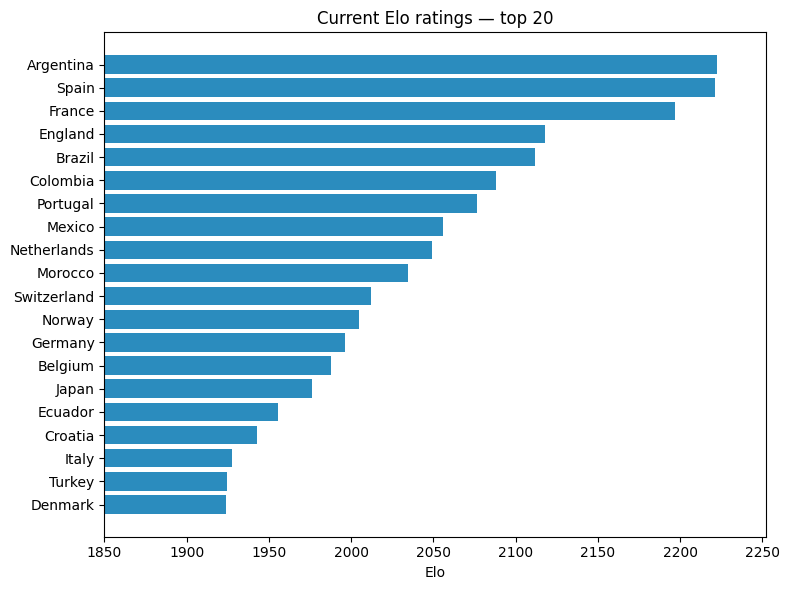

In [3]:
top = sorted(ratings.items(), key=lambda x: -x[1])[:20]
names = [t for t, _ in top][::-1]; vals = [v for _, v in top][::-1]
plt.figure(figsize=(8, 6))
plt.barh(names, vals, color="#2b8cbe")
plt.xlim(1850, max(vals) + 30); plt.title("Current Elo ratings — top 20"); plt.xlabel("Elo")
plt.tight_layout(); plt.show()

## 2 · The trained goal model — Poisson regression + Dixon-Coles

We stack every modern match (2002+) into a *team-perspective* view (one row per team per match) and
fit a **weighted Poisson regression** for goals scored:

$$\log \lambda = \beta_0 + \beta_1\cdot\frac{R_\text{team}-R_\text{opp}}{100} + \beta_2\cdot \text{is\_home}$$

Recent matches get more weight (exponential decay, 8-year half-life). We then fit the **Dixon-Coles**
dependence parameter `ρ`, which corrects the independent-Poisson under-count of 0-0/1-0/0-1/1-1 —
critical for realistic knockout draw rates.

In [4]:
MODERN_FROM, HALF_LIFE = "2002-01-01", 365 * 8

def build_training(ann, asof):
    d = ann[ann.date >= MODERN_FROM].copy()
    d["w"] = 0.5 ** ((asof - d.date).dt.days.clip(lower=0) / HALF_LIFE)
    neutral = d.neutral.fillna(False).astype(bool)
    home = pd.DataFrame({"goals": d.home_score.astype(int),
                         "elo_diff": (d.rh_pre - d.ra_pre) / 100.0,
                         "is_home": (~neutral).astype(float), "w": d.w})
    away = pd.DataFrame({"goals": d.away_score.astype(int),
                         "elo_diff": (d.ra_pre - d.rh_pre) / 100.0,
                         "is_home": 0.0, "w": d.w})
    return pd.concat([home, away], ignore_index=True)

def fit_poisson(tr):
    y = tr.goals.values.astype(float)
    X = np.column_stack([np.ones(len(tr)), tr.elo_diff.values, tr.is_home.values])
    w = tr.w.values
    def nll(b):
        eta = np.clip(X @ b, -3, 3)
        return -np.sum(w * (y * eta - np.exp(eta)))
    return minimize(nll, [0.0, 0.3, 0.2], method="BFGS").x

def expected_goals(beta, ediff, is_home):
    return float(np.exp(np.clip(beta[0] + beta[1]*ediff + beta[2]*is_home, -3, 3)))

def dc_tau(i, j, lh, la, rho):
    if i == 0 and j == 0: return 1.0 - lh*la*rho
    if i == 0 and j == 1: return 1.0 + lh*rho
    if i == 1 and j == 0: return 1.0 + la*rho
    if i == 1 and j == 1: return 1.0 - rho
    return 1.0

def fit_rho(ann, beta, asof):
    d = ann[ann.date >= MODERN_FROM].copy()
    neutral = d.neutral.fillna(False).astype(bool)
    ed = (d.rh_pre - d.ra_pre).values / 100.0
    hs, as_ = d.home_score.astype(int).values, d.away_score.astype(int).values
    w = 0.5 ** ((asof - d.date).dt.days.clip(lower=0).values / HALF_LIFE)
    lh = np.exp(np.clip(beta[0] + beta[1]*ed + beta[2]*(~neutral).astype(float).values, -3, 3))
    la = np.exp(np.clip(beta[0] - beta[1]*ed, -3, 3))
    mask = np.where((hs <= 1) & (as_ <= 1))[0]
    def nll(r):
        tau = np.ones(len(d))
        for idx in mask: tau[idx] = dc_tau(hs[idx], as_[idx], lh[idx], la[idx], r[0])
        return -np.sum(w * np.log(np.clip(tau, 1e-6, None)))
    return float(minimize(nll, [-0.05], method="Nelder-Mead").x[0])

def score_matrix(lh, la, rho, maxg=10):
    i = np.arange(maxg + 1)
    M = np.outer(poisson.pmf(i, lh), poisson.pmf(i, la))
    for a in (0, 1):
        for b in (0, 1): M[a, b] *= dc_tau(a, b, lh, la, rho)
    return M / M.sum()

beta = fit_poisson(build_training(annotated, asof))
rho  = fit_rho(annotated, beta, asof)
print(f"beta: intercept={beta[0]:.4f}  elo_diff/100={beta[1]:.4f}  is_home={beta[2]:.4f}")
print(f"Dixon-Coles rho = {rho:.4f}")

beta: intercept=0.0999  elo_diff/100=0.1841  is_home=0.2440
Dixon-Coles rho = -0.0472


## 3 · Honest backtest — does it actually predict?

Train the goal model on **2002–2022** and predict Win/Draw/Loss on **2023–2026** matches it never
saw. Elo uses only pre-match information (`rh_pre`/`ra_pre` are computed chronologically) so there is
**no leakage**. We compare to a base-rate baseline.

In [5]:
cut = pd.Timestamp("2023-01-01")
tr = annotated[annotated.date < cut]
b2 = fit_poisson(build_training(tr, cut)); r2 = fit_rho(tr, b2, cut)
te = annotated[annotated.date >= cut].dropna(subset=["home_score","away_score"])
trp = tr.dropna(subset=["home_score","away_score"])
base = np.array([(trp.home_score>trp.away_score).mean(), (trp.home_score==trp.away_score).mean(),
                 (trp.home_score<trp.away_score).mean()])
corr = ll = bll = 0
for m in te.itertuples(index=False):
    rd = (m.rh_pre - m.ra_pre)/100.0; ha = 0.0 if bool(getattr(m,"neutral",False)) else 1.0
    lh = expected_goals(b2, rd, ha); la = expected_goals(b2, -rd, 0)
    M = score_matrix(lh, la, r2)
    p = np.array([np.tril(M,-1).sum(), np.trace(M), np.triu(M,1).sum()]); p = np.clip(p,1e-9,None); p/=p.sum()
    y = 0 if m.home_score>m.away_score else (1 if m.home_score==m.away_score else 2)
    corr += p.argmax()==y; ll += -np.log(p[y]); bll += -np.log(base[y])
n = len(te)
print(f"Test matches (2023-2026): {n}")
print(f"Accuracy (W/D/L):        {corr/n:.3f}")
print(f"Model  log-loss:         {ll/n:.4f}")
print(f"Baseline log-loss:       {bll/n:.4f}  ->  {100*(bll-ll)/bll:.1f}% lower")

Test matches (2023-2026): 3686
Accuracy (W/D/L):        0.608
Model  log-loss:         0.8654
Baseline log-loss:       1.0536  ->  17.9% lower


## 4 · The 2026 bracket (Round of 16 → Final)

The Round of 32 is complete, so the Round of 16 is a fixed set of fixtures (home team first). The
quarterfinal / semifinal / final tree is the official bracket structure, verified against Wikipedia
and Sky Sports.

In [6]:
# Actual Round of 16 fixtures (home, away), in official match_id order
R16_FIXTURES = [
    ("Canada", "Morocco"),          # R16_001  @ Houston
    ("Paraguay", "France"),         # R16_002  @ Philadelphia
    ("Brazil", "Norway"),           # R16_003  @ East Rutherford
    ("Mexico", "England"),          # R16_004  @ Mexico City  (Mexico host)
    ("Portugal", "Spain"),          # R16_005  @ Dallas
    ("United States", "Belgium"),   # R16_006  @ Seattle       (USA host)
    ("Argentina", "Egypt"),         # R16_007  @ Atlanta
    ("Switzerland", "Colombia"),    # R16_008  @ Vancouver
]
QF_PAIRS   = [(0,1),(2,3),(4,5),(6,7)]   # each QF = winners of these two R16 fixtures
SF_PAIRS   = [(0,1),(2,3)]                # each SF = winners of these two QFs
FINAL_PAIR = (0,1); THIRD_PAIR = (0,1)
MATCH_IDS = {"R16-0":"R16_001","R16-1":"R16_002","R16-2":"R16_003","R16-3":"R16_004",
             "R16-4":"R16_005","R16-5":"R16_006","R16-6":"R16_007","R16-7":"R16_008",
             "QF-0":"QF_001","QF-1":"QF_002","QF-2":"QF_003","QF-3":"QF_004",
             "SF-0":"SF_001","SF-1":"SF_002","Third":"TP_001","Final":"F_001"}
STAGE_LABEL = {"R16":"Round of 16","QF":"Quarter Final","SF":"Semi Final",
               "Third":"Third Place Play-off","Final":"Final"}

def host_adv(team, rnd):
    if team == "United States": return 1.0        # all US knockout games in the USA
    if team == "Mexico" and rnd == "R16": return 1.0  # Mexico City
    return 0.0
print("R16 fixtures:", len(R16_FIXTURES))

R16 fixtures: 8


## 5 · Resolving matches and walking the bracket

For each match we compute the winner (higher **advance probability**, including extra-time/penalty
resolution of draws) and a coherent representative scoreline: the most-likely score in whichever
outcome category — decisive win vs draw-then-penalties — is more probable.

In [7]:
def elo_edge_draw(home, away, rnd):
    adv = (host_adv(home,rnd) - host_adv(away,rnd)) * HOME_ADV
    return 1.0 / (1.0 + 10 ** (-(((ratings[home]+adv) - ratings[away]))/400.0))

def predict_match(home, away, rnd):
    rd = (ratings[home] - ratings[away]) / 100.0
    lh = expected_goals(beta, rd, host_adv(home, rnd))
    la = expected_goals(beta, -rd, host_adv(away, rnd))
    M = score_matrix(lh, la, rho)
    p_home, p_away, p_draw = np.tril(M,-1).sum(), np.triu(M,1).sum(), np.trace(M)
    s = elo_edge_draw(home, away, rnd)
    p_home_adv = p_home + p_draw * s
    winner = home if p_home_adv >= 0.5 else away
    p_win_reg = p_home if winner == home else p_away
    decisive = p_win_reg >= p_draw
    best, bp = (0,0), -1.0
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            ok = ((i>j) if winner==home else (j>i)) if decisive else (i==j)
            if ok and M[i,j] > bp: bp, best = M[i,j], (i,j)
    return {"home":home,"away":away,"round":rnd,"home_score":best[0],"away_score":best[1],
            "winner":winner,"p_home_adv":round(p_home_adv,3)}

def deterministic_bracket():
    fx = []
    r16w = []
    for i,(h,a) in enumerate(R16_FIXTURES):
        p = predict_match(h,a,"R16"); p["slot"]=f"R16-{i}"; fx.append(p); r16w.append(p["winner"])
    qfw = []
    for q,(i,j) in enumerate(QF_PAIRS):
        p = predict_match(r16w[i],r16w[j],"QF"); p["slot"]=f"QF-{q}"; fx.append(p); qfw.append(p["winner"])
    sfw, sfl = [], []
    for si,(i,j) in enumerate(SF_PAIRS):
        p = predict_match(qfw[i],qfw[j],"SF"); p["slot"]=f"SF-{si}"; fx.append(p)
        sfw.append(p["winner"]); sfl.append(p["away"] if p["winner"]==p["home"] else p["home"])
    p = predict_match(sfl[THIRD_PAIR[0]], sfl[THIRD_PAIR[1]], "Third"); p["slot"]="Third"; fx.append(p)
    p = predict_match(sfw[FINAL_PAIR[0]], sfw[FINAL_PAIR[1]], "Final"); p["slot"]="Final"; fx.append(p)
    return fx

fixtures = deterministic_bracket()
pd.DataFrame([{"stage":STAGE_LABEL[f["round"]],"home":f["home"],
               "score":f'{f["home_score"]}-{f["away_score"]}',"away":f["away"],
               "winner":f["winner"]} for f in fixtures])

,stage,home,score,away,winner
0,Round of 16,Canada,0-1,Morocco,Morocco
1,Round of 16,Paraguay,0-1,France,France
2,Round of 16,Brazil,1-0,Norway,Brazil
3,Round of 16,Mexico,1-0,England,Mexico
4,Round of 16,Portugal,0-1,Spain,Spain
5,Round of 16,United States,1-0,Belgium,United States
6,Round of 16,Argentina,2-0,Egypt,Argentina
7,Round of 16,Switzerland,0-1,Colombia,Colombia
8,Quarter Final,Morocco,0-1,France,France
9,Quarter Final,Brazil,1-0,Mexico,Brazil


## 6 · Monte-Carlo — how confident are we?

The single deterministic bracket is one path. Simulating the whole tournament **50,000 times**
(sampling scorelines, extra time and shootouts) gives the probability each team lifts the trophy.

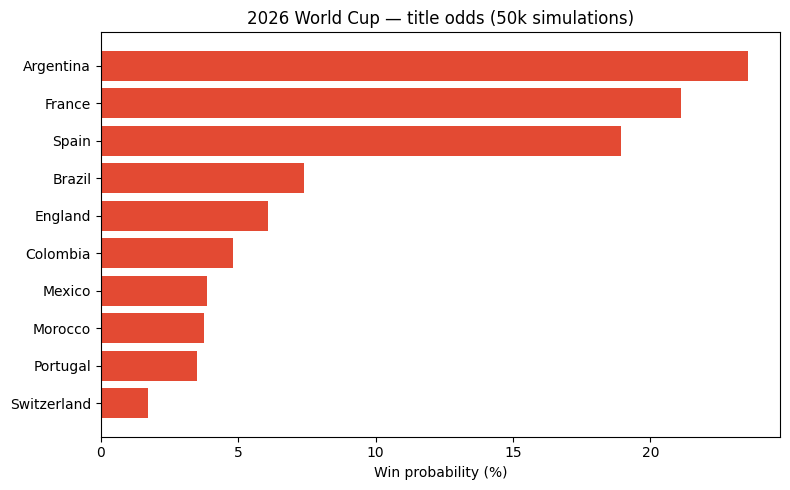

,team,champion,reaches_final
0,Argentina,23.5%,37.7%
1,France,21.1%,39.2%
2,Spain,18.9%,30.3%
3,Brazil,7.4%,16.8%
4,England,6.1%,13.5%
5,Colombia,4.8%,10.5%
6,Mexico,3.9%,10.4%
7,Morocco,3.8%,11.0%
8,Portugal,3.5%,7.8%
9,Switzerland,1.7%,4.6%


In [8]:
def sample_result(home, away, rnd, rng):
    lh = expected_goals(beta,(ratings[home]-ratings[away])/100.0, host_adv(home,rnd))
    la = expected_goals(beta,(ratings[away]-ratings[home])/100.0, host_adv(away,rnd))
    hs, as_ = rng.poisson(lh), rng.poisson(la)
    if hs != as_: return home if hs>as_ else away
    hs += rng.poisson(lh/3); as_ += rng.poisson(la/3)
    if hs != as_: return home if hs>as_ else away
    return home if rng.random() < 0.5 + 0.5*(elo_edge_draw(home,away,rnd)-0.5) else away

def monte_carlo(n=50000, seed=42):
    rng = np.random.default_rng(seed); champ={}; final={}
    for _ in range(n):
        r16w = [sample_result(h,a,"R16",rng) for h,a in R16_FIXTURES]
        qfw  = [sample_result(r16w[i],r16w[j],"QF",rng) for i,j in QF_PAIRS]
        sfw  = [sample_result(qfw[i],qfw[j],"SF",rng) for i,j in SF_PAIRS]
        fh, fa = sfw[FINAL_PAIR[0]], sfw[FINAL_PAIR[1]]
        final[fh]=final.get(fh,0)+1; final[fa]=final.get(fa,0)+1
        c = sample_result(fh,fa,"Final",rng); champ[c]=champ.get(c,0)+1
    f=lambda d:{k:v/n for k,v in sorted(d.items(),key=lambda x:-x[1])}
    return f(champ), f(final)

champ, final = monte_carlo(50000)
tt = list(champ.items())[:10][::-1]
plt.figure(figsize=(8,5))
plt.barh([t for t,_ in tt], [p*100 for _,p in tt], color="#e34a33")
plt.xlabel("Win probability (%)"); plt.title("2026 World Cup — title odds (50k simulations)")
plt.tight_layout(); plt.show()
pd.DataFrame([{"team":t,"champion":f"{p:.1%}","reaches_final":f"{final.get(t,0):.1%}"}
              for t,p in list(champ.items())[:10]])

## 7 · Goalscorers

Each team's goalscorers over the last few years (recency-weighted, own goals removed) are ranked,
then mapped onto **verified 2026 shirt numbers**. The top-ranked available scorer is assigned per
predicted goal — the optimal single guess for a one-goal game.

In [9]:
SQUAD_NUMBERS = {
 "Argentina":{"Lionel Messi":10,"Lautaro Martínez":22,"Julián Álvarez":9},
 "France":{"Kylian Mbappé":10,"Ousmane Dembélé":7,"Randal Kolo Muani":12},
 "Brazil":{"Vinícius Júnior":7,"Raphinha":11,"Neymar":10,"Matheus Cunha":19},
 "Spain":{"Mikel Oyarzabal":21,"Ferran Torres":7,"Lamine Yamal":19,"Mikel Merino":6,"Dani Olmo":10,"Gavi":9},
 "England":{"Harry Kane":9,"Jude Bellingham":10,"Bukayo Saka":7},
 "Morocco":{"Ayoub El Kaabi":20,"Brahim Díaz":10,"Achraf Hakimi":2},
 "United States":{"Christian Pulisic":10,"Weston McKennie":8},
 "Colombia":{"Luis Díaz":7,"James Rodríguez":10,"Jhon Córdoba":9},
 "Mexico":{"Raúl Jiménez":9,"Santiago Giménez":11}}
ALIASES = {"Julián Alvarez":"Julián Álvarez","Vinicius Júnior":"Vinícius Júnior","Vinicius Junior":"Vinícius Júnior"}

def scorer_ranking(since="2021-01-01", hl=2.5):
    g = goalscorers.copy(); g["date"]=pd.to_datetime(g["date"])
    a = g.date.max()
    g = g[(~g.own_goal.fillna(False)) & (g.date>=since)].copy()
    g["w"] = 0.5 ** ((a - g.date).dt.days/(365*hl))
    g["player"] = g.scorer.map(lambda n: ALIASES.get(n,n))
    r = g.groupby(["team","player"]).w.sum().reset_index().sort_values(["team","w"],ascending=[True,False])
    return {t:list(s.player) for t,s in r.groupby("team")}

ranking = scorer_ranking()
def pick_scorers(team, n):
    if n<=0: return []
    nums = SQUAD_NUMBERS.get(team,{}); chosen=[]
    for name in ranking.get(team,[]):
        if name in nums and nums[name] not in chosen: chosen.append(nums[name])
        if len(chosen)>=n: break
    if not chosen and nums: chosen=[sorted(nums.values())[0]]
    while len(chosen)<n and chosen: chosen.append(chosen[0])
    return chosen[:n]
print("Argentina ->", pick_scorers("Argentina",1), "| Mexico ->", pick_scorers("Mexico",1))

Argentina -> [10] | Mexico -> [9]


## 8 · Fill the submission template

In [10]:
by_id = {}
for f in fixtures:
    hs, as_ = f["home_score"], f["away_score"]
    by_id[MATCH_IDS[f["slot"]]] = {
        "home_team":f["home"],"away_team":f["away"],
        "predicted_home_score":hs,"predicted_away_score":as_,
        "predicted_scorers_home":";".join(map(str,pick_scorers(f["home"],hs))),
        "predicted_scorers_away":";".join(map(str,pick_scorers(f["away"],as_))),
        "predicted_winner":f["winner"]}

sub = pd.read_csv(TMPL/"mufifa26_template.csv", dtype=str, keep_default_na=False)
for i,row in sub.iterrows():
    if row["match_id"] in by_id:
        for k,v in by_id[row["match_id"]].items(): sub.at[i,k]=v
sub.to_csv(OUT/"predictions.csv", index=False)

viol = 0
for _,r in sub.iterrows():
    nh = 0 if r.predicted_scorers_home=="" else len(r.predicted_scorers_home.split(";"))
    na = 0 if r.predicted_scorers_away=="" else len(r.predicted_scorers_away.split(";"))
    if nh>int(r.predicted_home_score) or na>int(r.predicted_away_score) or not r.home_team: viol+=1
print(f"Wrote {OUT/'predictions.csv'} | rows={len(sub)} | violations={viol}")
sub

Wrote /home/anzil/AI/muFIFA/output/predictions.csv | rows=16 | violations=0


,match_id,stage,home_team,away_team,predicted_home_score,predicted_away_score,predicted_scorers_home,predicted_scorers_away,predicted_winner
0,R16_001,Round of 16,Canada,Morocco,0,1,,20,Morocco
1,R16_002,Round of 16,Paraguay,France,0,1,,10,France
2,R16_003,Round of 16,Brazil,Norway,1,0,7,,Brazil
3,R16_004,Round of 16,Mexico,England,1,0,9,,Mexico
4,R16_005,Round of 16,Portugal,Spain,0,1,,21,Spain
5,R16_006,Round of 16,United States,Belgium,1,0,10,,United States
6,R16_007,Round of 16,Argentina,Egypt,2,0,10;22,,Argentina
7,R16_008,Round of 16,Switzerland,Colombia,0,1,,7,Colombia
8,QF_001,Quarter Final,Morocco,France,0,1,,10,France
9,QF_002,Quarter Final,Brazil,Mexico,1,0,7,,Brazil


## Conclusion

**🇦🇷 Argentina are predicted champions**, edging France in the final, with Brazil and Spain the other
semifinalists — consistent with the Monte-Carlo favourites (a genuine three-way race at the top).
Host advantage tips the tightest R16 tie: **Mexico** edge England in Mexico City.

**Honest limitations:** winners/bracket are far more reliable than exact scores; football is
low-scoring and high-variance, so every knockout scoreline is the single *most-likely* exact score
(usually 1-0 between good sides). Scorers are a best-effort heuristic (each team's top goal threat,
the optimal single guess per match). The Round of 16 here is the *actual* field; to re-run after any
later round, refresh the data (`bash data/download.sh`) — ratings update and the bracket regenerates.